!pip install pylabwons

# RESOURCES

## ASSET



| 구분 | XLE (대형주 중심) | XOP (탐사/생산 중심) | WTIU (3배 레버리지) |
| :--- | :--- | :--- | :--- |
| **기초 자산** | S&P 500 에너지 섹터 기업 | S&P Oil & Gas E&P 지수 | Solactive MicroSectors US Big Oil Index |
| **가중 방식** | **시가총액 가중** (대형주 비중↑) | **동일 가중** (모든 종목 균등 비중) | **동일 가중** (상위 12개 대형주 중심) |
| **운용 방식** | 1배수 (현물 ETF) | 1배수 (현물 ETF) | **일일 수익률 3배 추종 (ETN)** |
| **주요 종목** | 엑손모빌, 쉐브론 등 대기업 | 중소형 탐사·생산(E&P) 기업 | 엑손모빌, 쉐브론 등 우량주 12개 |
| **운용 보수** | **0.09%** | 0.35% | **0.95%** |
| **주요 특징** | 안정적인 대형주 및 배당 중심 | 유가 변동에 민감한 중소형주 포함 | 단기 방향성 매매용 (변동성 매우 높음) |


In [ ]:
import yfinance as yf
import pandas as pd
import pandas_datareader.data as web
from datetime import datetime


# XOP: Energy Select Sector SPDR Fund
# XLE: SPDR S&P Oil & Gas Exploration & Production ETF
xop = yf.Ticker('XOP')
xle = yf.Ticker('XLE')
lev = yf.Ticker('WTIU')

objs = {}
for ticker in [xop, xle, lev]:
    ohlcv = ticker.history(period='10y', interval='1d')[['Open', 'High', 'Low', 'Close', 'Volume']]
    ohlcv.columns = ['open', 'high', 'low', 'close', 'volume']
    objs[ticker.ticker] = ohlcv
    

asset = pd.concat(objs, axis=1)
asset.index = asset.index.date

## FUTURES

In [32]:
# CL=F: WTI Crude Oil Futures
# BZ=F: Brent Crude Oil Futures
# NG=F: Natural Gas Futures
cl_f = yf.Ticker('CL=F')
bz_f = yf.Ticker('BZ=F')
ng_f = yf.Ticker('NG=F')
objs = {}
for ticker in [cl_f, bz_f, ng_f]:
    ohlcv = ticker.history(period='10y', interval='1d')[['Open', 'High', 'Low', 'Close', 'Volume']]
    ohlcv.columns = ['open', 'high', 'low', 'close', 'volume']
    objs[ticker.ticker] = ohlcv
futures = pd.concat(objs, axis=1)
futures.index = futures.index.date

## DXY

In [35]:
# DX-Y.NYB: US Dollar Index
dxy = yf.Ticker('DX-Y.NYB').history(period='10y', interval='1d')[['Open', 'High', 'Low', 'Close', 'Volume']]
dxy.columns = ['open', 'high', 'low', 'close', 'volume']
dxy.index = dxy.index.date

## OTHERS

* TREASURY YIELD
* CRUDE STOCKS
* BRENT GLOBAL PRICE
* OIL & GAS PPI

In [36]:
# DGS10: 10-Year Treasury Constant Maturity Rate
# T10Y2Y: 10-Year Treasury Constant Maturity Minus 2-Year Treasury
# M05F3BUSM386NNBR: Crude Petroleum Stocks for United States
# POILBREUSDM: Global price of Brent Crude
# PCU213111213111: Producer Price Index by Industry: Drilling Oil and Gas Wells
today = datetime.now()
start = datetime(today.year - 10, today.month, today.day)
others = web.DataReader(['DGS10', 'T10Y2Y', 'M05F3BUSM386NNBR', 'POILBREUSDM', 'PCU213111213111'], 'fred', start, today)

# ANALYTICS

In [71]:
# INITIALIZE
import matplotlib.pyplot as plt
import pandas as pd
from datetime import timedelta

def plot_dual_axis(s1: pd.Series, s2: pd.Series, **kwargs):
    # 다크 모드 적용
    plt.style.use('dark_background')
    
    # 1. 데이터 전처리: 두 데이터의 인덱스를 맞춤 (Inner Join)
    df = pd.concat([s1, s2], axis=1).dropna()
    df.columns = ['s1', 's2']

    # 2. 상관계수 계산 (전체, 5년, 3년, 1년, 6개월)
    df.index = pd.to_datetime(df.index)
    last_date = df.index.max()

    periods = {
        'All': df,
        '5Y': df[df.index > last_date - pd.DateOffset(years=5)],
        '3Y': df[df.index > last_date - pd.DateOffset(years=3)],
        '1Y': df[df.index > last_date - pd.DateOffset(years=1)],
        '6M': df[df.index > last_date - pd.DateOffset(months=6)]
    }
    
    corr_texts = []
    for label, data in periods.items():
        if len(data) > 1: # 데이터가 충분할 때만 계산
            corr_val = data['s1'].corr(data['s2'])
            corr_texts.append(f"{label}: {corr_val:.2f}")
    
    corr_display = "[Correlation]\n" + "\n".join(corr_texts)

    # 3. 그래프 생성
    figsize = kwargs.get('figsize', (12, 6))
    fig, ax1 = plt.subplots(figsize=figsize)

    name1 = kwargs.get('ax1_name', s1.name if s1.name else 'Axis 1')
    name2 = kwargs.get('ax2_name', s2.name if s2.name else 'Axis 2')
    color1 = kwargs.get('color1', 'tab:blue')
    color2 = kwargs.get('color2', 'tab:orange')
    title = kwargs.get('title', f'{name1} vs {name2}')

    # 왼쪽 축
    lns1 = ax1.plot(df.index, df['s1'], color=color1, label=name1)
    ax1.set_xlabel('Date')
    ax1.set_ylabel(name1, color=color1)
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.grid(True, alpha=0.1)

    # 오른쪽 축
    ax2 = ax1.twinx()
    lns2 = ax2.plot(df.index, df['s2'], color=color2, label=name2)
    ax2.set_ylabel(name2, color=color2)
    ax2.tick_params(axis='y', labelcolor=color2)

    # 4. Annotation 추가 (상관계수 텍스트 박스)
    # axes coordinates (0,0 is bottom-left, 1,1 is top-right)
    ax1.annotate(corr_display, xy=(0.02, 0.95), xycoords='axes fraction',
                 verticalalignment='top', fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.5', facecolor='gray', alpha=0.2))

    # 5. 범례 및 마무리
    lns = lns1 + lns2
    labs = [l.get_label() for l in lns]
    ax1.legend(lns, labs, loc='upper right')

    plt.title(title)
    fig.tight_layout()
    plt.show()


## 01. PE

In [42]:
print(f'XLE: \n  - TRAILING PE: {xle.info.get("trailingPE")}\n  - FORWARD PE: {xle.info.get("forwardPE")}')
print(f'XOP: \n  - TRAILING PE: {xop.info.get("trailingPE")}\n  - FORWARD PE: {xop.info.get("forwardPE")}')

XLE: 
  - TRAILING PE: 20.342041
  - FORWARD PE: None
XOP: 
  - TRAILING PE: 13.243633
  - FORWARD PE: -16606.0


## 02. ASSET-DXY

### 02.01 PLOT

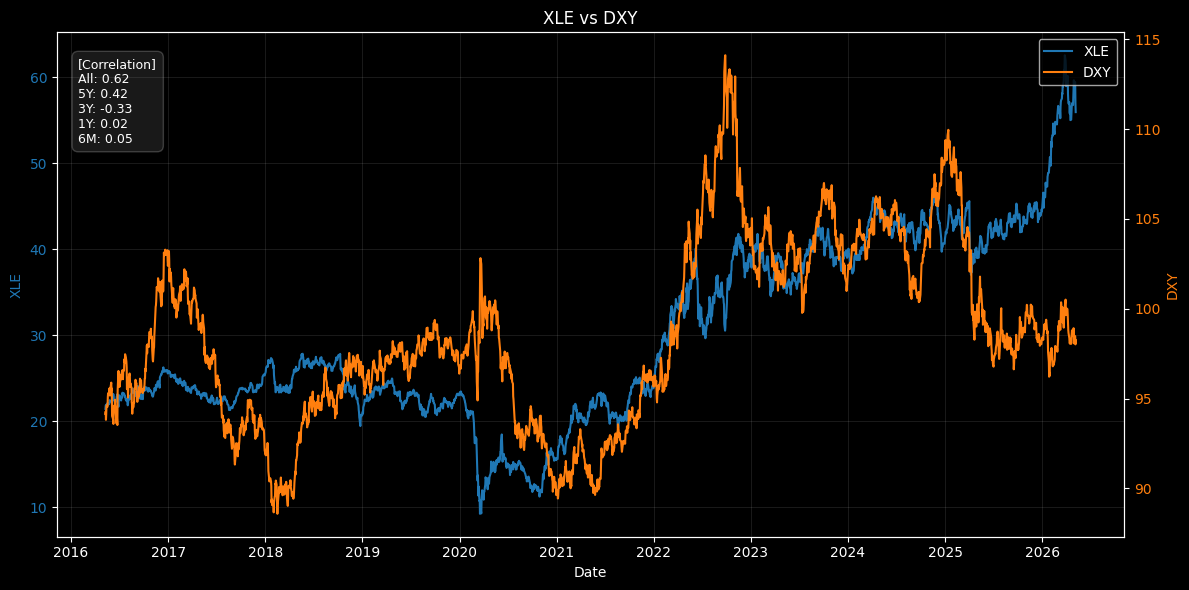

In [72]:
plot_dual_axis(
    s1=asset['XLE']['close'],
    s2=dxy['close'],
    ax1_name='XLE',
    ax2_name='DXY'
)